# **Case Study - Improving Conversion for a Key Feature**
**Name**: Jorge Polanco Roque

**Date**: 0225

## 🎯 Hypothesis Before Statistical Testing

Before running hypothesis tests, we define our assumptions:

1️⃣ **Stage Drop-Off Hypothesis**  
   - Users dropping off between **Browsing → Add to Cart** may be experiencing friction in product discovery.  
   - Possible reasons: confusing product descriptions, unclear pricing, or lack of trust in the checkout process.  

2️⃣ **Demographic & Device Hypothesis**  
   - We suspect that conversion rates **vary significantly** across devices and demographic groups.  
   - Example: Mobile users may have lower conversions due to small screen usability issues.  

3️⃣ **Location-Based Hypothesis**  
   - Rural users might have lower conversion rates due to **longer shipping times** or **limited payment options**.  
   - We will check if there are statistically significant differences in conversion rates across locations.  

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from itertools import combinations
from scipy.stats import kruskal
import scikit_posthocs as sp
import plotly.graph_objects as go


In [2]:
# Set seaborn style with the custom palette
custom_palette = ["#00A8E8", "#FFDD44", "#8F00FF", "#34C759", "#FF5722"]

sns.set_theme(style="whitegrid", palette=custom_palette, context="talk")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams['axes.facecolor'] = custom_palette[3]

# **Step 1**: Data Overview and Summary Statistics

In [3]:
# Open the CSV file
df = pd.read_csv('user_funnel_data.csv')

# Changing the formating
df['Conversion_Rate'] = df['Conversion_Rate'].str.replace('%', '').str.replace(',', '.').astype(float)

print("Shape of the DF: ", df.shape)
df.head(3)

Shape of the DF:  (1000, 6)


,User_ID,Stage_Conversion,Demographic_Group,Device,Location,Conversion_Rate
0,1,Account Setup,Group B,Desktop,Urban,55.85
1,2,Browsing,Group A,Mobile,Suburban,28.79
2,3,Account Setup,Group A,Mobile,Suburban,62.83


In [4]:
print("DataFrame Overview:")
print(df.info())

DataFrame Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            1000 non-null   int64  
 1   Stage_Conversion   1000 non-null   object 
 2   Demographic_Group  1000 non-null   object 
 3   Device             1000 non-null   object 
 4   Location           1000 non-null   object 
 5   Conversion_Rate    1000 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 47.0+ KB
None


In [5]:
print("\nSummary Statistics:")
print(df['Conversion_Rate'].describe().round(2))


Summary Statistics:
count    1000.00
mean       62.95
std        34.95
min         4.02
25%        29.49
50%        61.19
75%       100.00
max       100.00
Name: Conversion_Rate, dtype: float64


**Defining logics behind each categorical variables**:

In [6]:
df.head()

,User_ID,Stage_Conversion,Demographic_Group,Device,Location,Conversion_Rate
0,1,Account Setup,Group B,Desktop,Urban,55.85
1,2,Browsing,Group A,Mobile,Suburban,28.79
2,3,Account Setup,Group A,Mobile,Suburban,62.83
3,4,Account Setup,Group B,Mobile,Rural,68.95
4,5,Account Setup,Group A,Desktop,Rural,54.19


In [7]:
# Define the custom order of funnel stages
funnel_order = ["Registration", "Account Setup", "Browsing", "Add to Cart", "Purchase"]
demographic_order = ["Group A", "Group B", "Group C"]

# Ensure the categorical order in the DataFrame
df["Stage_Conversion"] = pd.Categorical(df["Stage_Conversion"], categories=funnel_order, ordered=True)
df["Demographic_Group"] = pd.Categorical(df["Demographic_Group"], categories=demographic_order, ordered=True)

In [ ]:
# Stage Conversion flow
fig = go.Figure(go.Sankey(
    node=dict(label=["Registration", "Account Setup", "Browsing", "Add to Cart", "Purchase"]),
    link=dict(source=[0,1,2,3], target=[1,2,3,4], value=[10000, 5900, 3500, 1900])
))

fig.show()

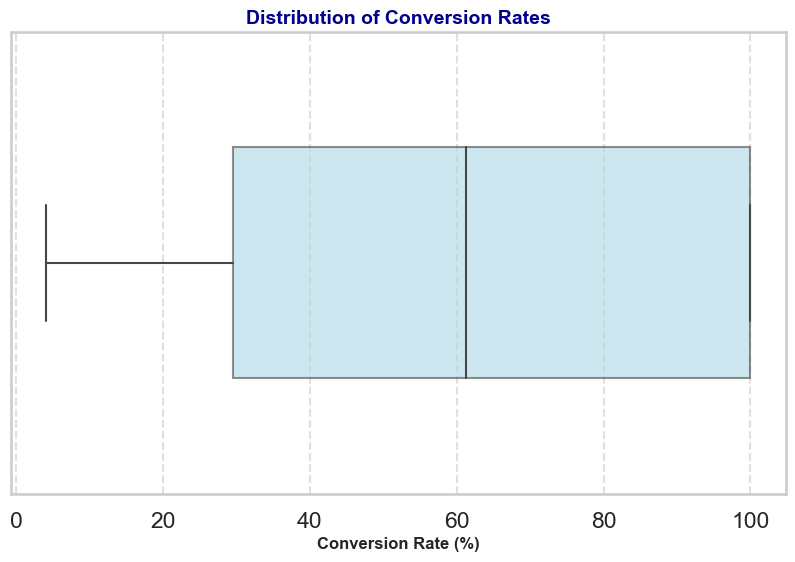

In [9]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create an enhanced boxplot
ax = sns.boxplot(x=df["Conversion_Rate"], width=0.5, linewidth=1.5, fliersize=5, boxprops=dict(facecolor="lightblue", alpha=0.6))

# Add title and labels with better formatting
plt.title("Distribution of Conversion Rates", fontsize=14, fontweight="bold", color="darkblue")
plt.xlabel("Conversion Rate (%)", fontsize=12, fontweight="bold")

# Adjust grid and background
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.gca().set_facecolor("white")

# Show the improved boxplot
plt.show()


**Device Distribution Analysis**:

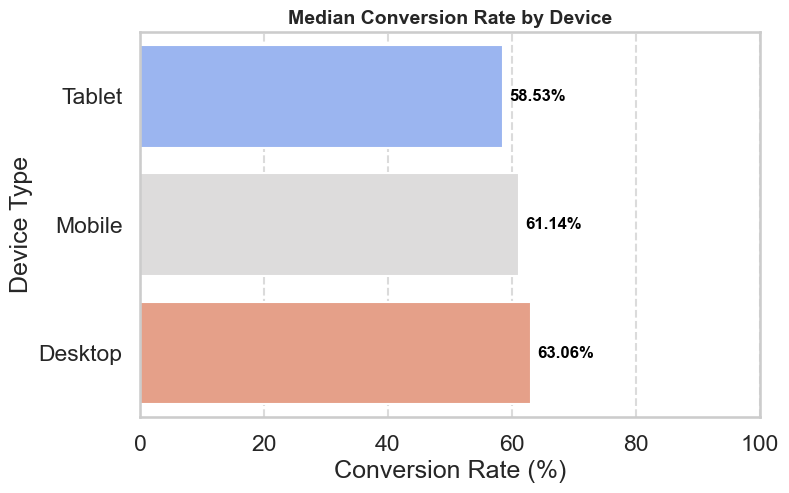

In [10]:
# Calculate average conversion rate per device
device_avg = df.groupby("Device")["Conversion_Rate"].median().reset_index()

# Sort devices by conversion rate for better readability
device_avg = device_avg.sort_values("Conversion_Rate", ascending=True)

# Set figure size
plt.figure(figsize=(8, 5))

# Create a horizontal bar chart
ax = sns.barplot(y="Device", x="Conversion_Rate", data=device_avg, palette="coolwarm")

# Add title and labels
plt.title("Median Conversion Rate by Device", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Device Type")
plt.xlim(0, 100)  # Ensure percentage scale is clear
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Display conversion rate values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',  # Format as percentage with 2 decimals
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Adjust position
                ha="left", va="center", fontsize=12, color="black", fontweight="bold")

# Set background to white
plt.gca().set_facecolor('white')

# Show the improved graph
plt.show()

**Demographic Group Distribution Analysis**:

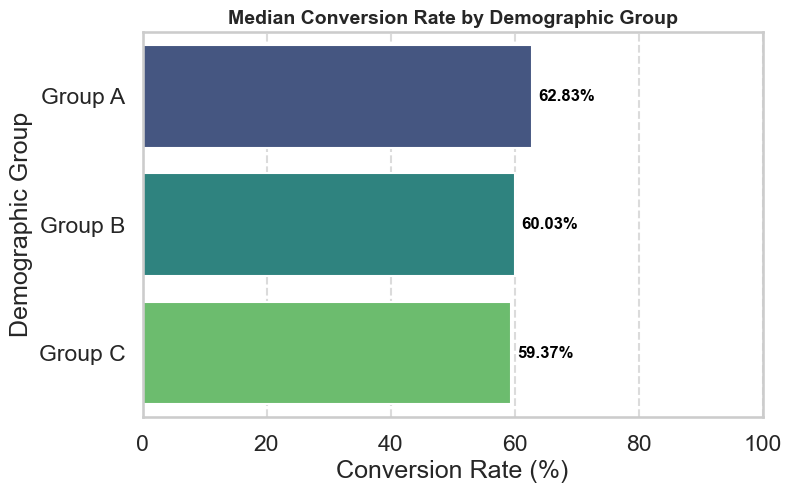

In [11]:
# Calculate average conversion rate per demographic group
demo_avg = df.groupby("Demographic_Group")["Conversion_Rate"].median().reset_index()

# Sort demographic groups by conversion rate for better readability
demo_avg = demo_avg.sort_values("Conversion_Rate", ascending=True)

# Set figure size
plt.figure(figsize=(8, 5))

# Create a horizontal bar chart
ax = sns.barplot(y="Demographic_Group", x="Conversion_Rate", data=demo_avg, palette="viridis")

# Add title and labels
plt.title("Median Conversion Rate by Demographic Group", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Demographic Group")
plt.xlim(0, 100)  # Ensure percentage scale is clear
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Display conversion rate values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',  # Format as percentage with 2 decimals
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Adjust position
                ha="left", va="center", fontsize=12, color="black", fontweight="bold")

# Set background to white
plt.gca().set_facecolor('white')

# Show the improved graph
plt.show()

**Location Distribution Analysis**:

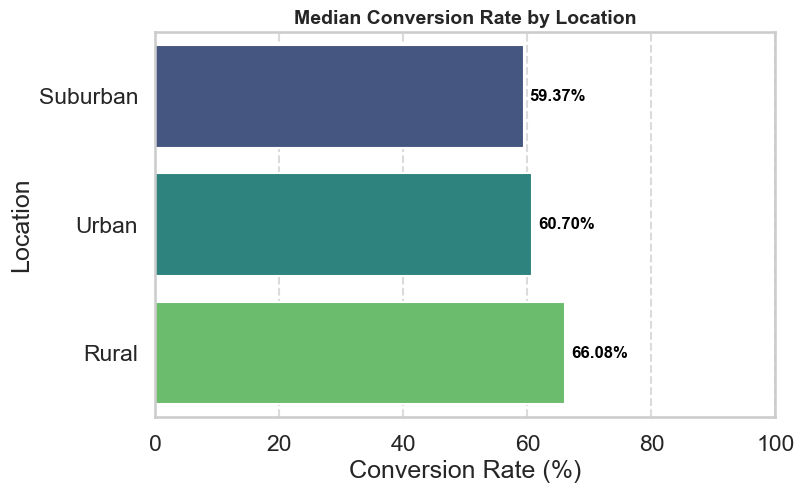

In [12]:
# Calculate median conversion rate per location
location_avg = df.groupby("Location")["Conversion_Rate"].median().reset_index()

# Sort locations by conversion rate for better readability
location_avg = location_avg.sort_values("Conversion_Rate", ascending=True)

# Set figure size
plt.figure(figsize=(8, 5))

# Create a horizontal bar chart
ax = sns.barplot(y="Location", x="Conversion_Rate", data=location_avg, palette="viridis")

# Add title and labels
plt.title("Median Conversion Rate by Location", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Location")
plt.xlim(0, 100)  # Ensure percentage scale is clear
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Display conversion rate values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',  # Format as percentage with 2 decimals
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Adjust position
                ha="left", va="center", fontsize=12, color="black", fontweight="bold")

# Set background to white
plt.gca().set_facecolor('white')

# Show the improved graph
plt.show()


**Funnel Stage Distribution Analysis**:

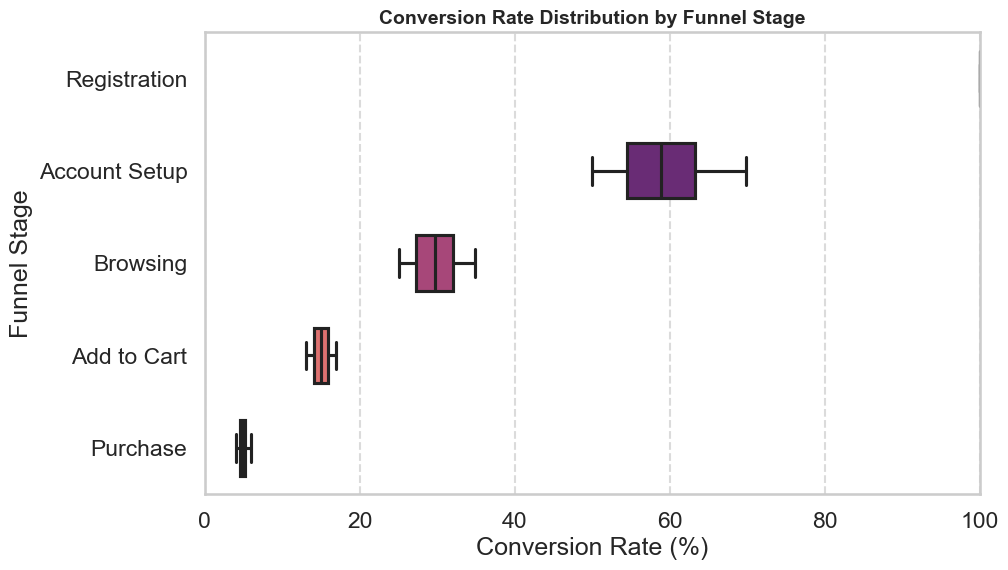

In [13]:
# Set figure size
plt.figure(figsize=(10, 6))

# Create a boxplot to show the distribution of conversion rates for each funnel stage
sns.boxplot(y="Stage_Conversion", x="Conversion_Rate", data=df, palette="magma", width=0.6)

# Add title and labels
plt.title("Conversion Rate Distribution by Funnel Stage", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Funnel Stage")
plt.xlim(0, 100)  # Ensure percentage scale is clear
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Add grid lines for better readability

# Set background to white
plt.gca().set_facecolor('white')

# Show the boxplot
plt.show()

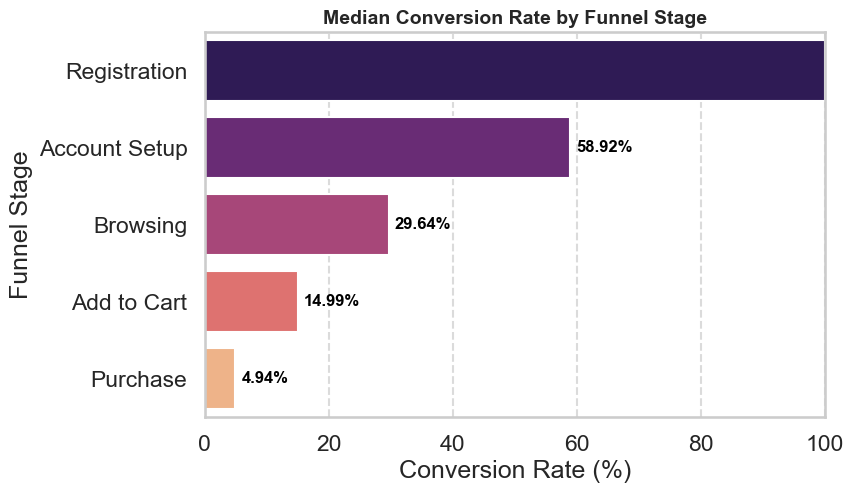

In [14]:
# Group by funnel stage and calculate the average conversion rate
stage_avg = df.groupby("Stage_Conversion")["Conversion_Rate"].median().reset_index()

# Apply the custom order to the Stage_Conversion column
stage_avg["Stage_Conversion"] = pd.Categorical(stage_avg["Stage_Conversion"], categories=funnel_order, ordered=True)

# Sort the DataFrame based on the defined order
stage_avg = stage_avg.sort_values("Stage_Conversion")

# Set figure size
plt.figure(figsize=(8, 5))

# Create a horizontal bar chart
ax = sns.barplot(y="Stage_Conversion", x="Conversion_Rate", data=stage_avg, palette="magma")

# Add title and labels
plt.title("Median Conversion Rate by Funnel Stage", fontsize=14, fontweight="bold")
plt.xlabel("Conversion Rate (%)")
plt.ylabel("Funnel Stage")
plt.xlim(0, 100)  # Ensure percentage scale is clear
plt.grid(axis="x", linestyle="--", alpha=0.7)  # Add grid lines for readability

# Display conversion rate values on the bars
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}%',  # Format as percentage with 2 decimals
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),  # Adjust position
                ha="left", va="center", fontsize=12, color="black", fontweight="bold")

# Set background to white
plt.gca().set_facecolor('white')

# Show the improved graph
plt.show()

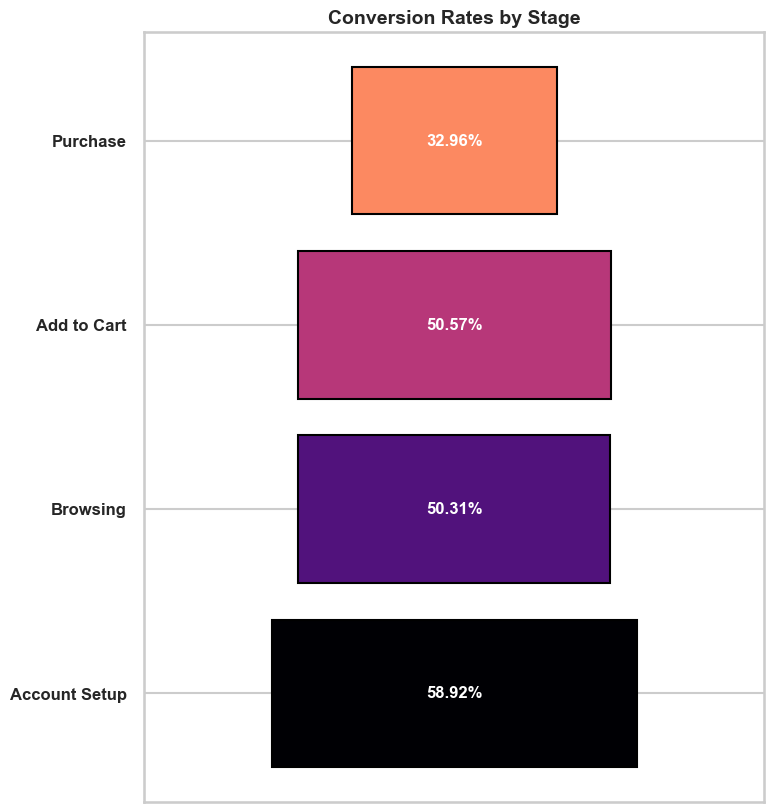

In [ ]:
# Sample Data: Ensure the structure follows your expected input
df_sc = pd.DataFrame({
    "Stage_Conversion": ["Account Setup", "Browsing", "Add to Cart", "Purchase"],
    "Conversion_Rate": [
        round((stage_avg.loc[stage_avg["Stage_Conversion"]=="Account Setup", "Conversion_Rate"].values[0] /
               stage_avg.loc[stage_avg["Stage_Conversion"]=="Registration", "Conversion_Rate"].values[0]) * 100, 2),

        round((stage_avg.loc[stage_avg["Stage_Conversion"]=="Browsing", "Conversion_Rate"].values[0] /
               stage_avg.loc[stage_avg["Stage_Conversion"]=="Account Setup", "Conversion_Rate"].values[0]) * 100, 2),

        round((stage_avg.loc[stage_avg["Stage_Conversion"]=="Add to Cart", "Conversion_Rate"].values[0] /
               stage_avg.loc[stage_avg["Stage_Conversion"]=="Browsing", "Conversion_Rate"].values[0]) * 100, 2),

        round((stage_avg.loc[stage_avg["Stage_Conversion"]=="Purchase", "Conversion_Rate"].values[0] /
               stage_avg.loc[stage_avg["Stage_Conversion"]=="Add to Cart", "Conversion_Rate"].values[0]) * 100, 2)
    ]
})

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 10))

# Define the maximum width for the top bar
max_width = 100  

# Create the inverted pyramid effect
for i, (stage, rate) in enumerate(zip(df_sc["Stage_Conversion"], df_sc["Conversion_Rate"])):
    width = rate  # Bar width is proportional to conversion rate
    ax.barh(stage, width, left=(max_width - width) / 2, color=plt.cm.magma(i / len(df_sc)), edgecolor="black")

# Formatting
ax.set_xlim(0, max_width)  # Set the x-axis limit
ax.set_xticks([])  # Hide x-axis ticks for clarity
ax.set_yticks(range(len(df_sc)))  # Set y-ticks for each stage
ax.set_yticklabels(df_sc["Stage_Conversion"], fontsize=12, fontweight="bold")  # Funnel stage labels
ax.set_title("Conversion Rates by Stage", fontsize=14, fontweight="bold")

# Display conversion rate values inside bars
for i, (stage, rate) in enumerate(zip(df_sc["Stage_Conversion"], df_sc["Conversion_Rate"])):
    ax.text(max_width / 2, i, f"{rate:.2f}%", ha="center", va="center", fontsize=12, color="white", fontweight="bold")

# Set background to white
plt.gca().set_facecolor('white')

# Show the inverted pyramid chart
plt.show()

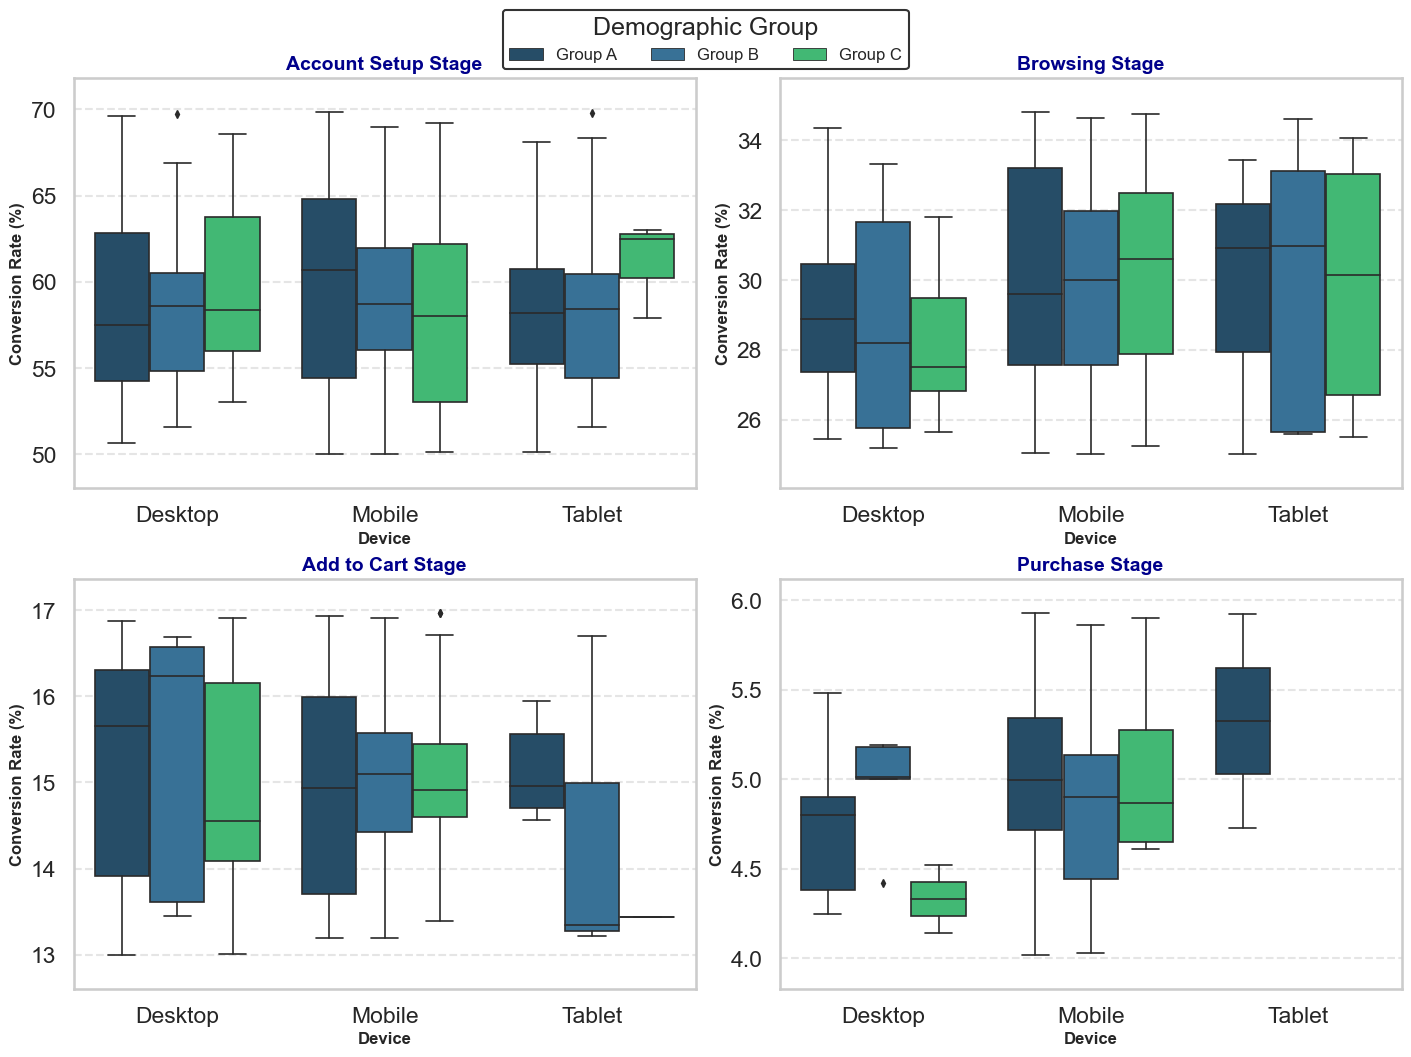

In [16]:
# Define the order of funnel stages, demographic groups, and devices
funnel_order = ["Account Setup", "Browsing", "Add to Cart", "Purchase"]
demographic_order = ["Group A", "Group B", "Group C"]
device_order = ["Desktop", "Mobile", "Tablet"]

# Ensure categorical order in the DataFrame
df["Demographic_Group"] = pd.Categorical(df["Demographic_Group"], categories=demographic_order, ordered=True)
df["Device"] = pd.Categorical(df["Device"], categories=device_order, ordered=True)

# Set up the grid layout for subplots (2x2 for readability)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Define a high-contrast color palette
palette = sns.color_palette(["#1B4F72", "#2874A6", "#2ECC71"])

# Iterate over each funnel stage and create a subplot
for i, stage in enumerate(funnel_order):
    if i >= len(axes):  # Prevent index errors if there are fewer subplots than grid spaces
        break

    # Filter data for the current stage
    stage_df = df[df["Stage_Conversion"] == stage]

    # Create boxplot with adaptive y-limits
    sns.boxplot(x="Device", y="Conversion_Rate", hue="Demographic_Group", data=stage_df,
                palette=palette, ax=axes[i], linewidth=1.2, fliersize=4)

    # Formatting
    axes[i].set_title(f"{stage} Stage", fontsize=14, fontweight="bold", color="darkblue")
    axes[i].set_xlabel("Device", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Conversion Rate (%)", fontsize=12, fontweight="bold")

    # Adjust y-axis dynamically based on data range
    if not stage_df.empty:
        min_val = stage_df["Conversion_Rate"].min()
        max_val = stage_df["Conversion_Rate"].max()
        buffer = (max_val - min_val) * 0.1 if max_val > min_val else 5  # 10% buffer for better spacing
        axes[i].set_ylim(min_val - buffer, max_val + buffer)

    # Add grid lines for better readability
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

    # Remove individual legends
    axes[i].legend_.remove()

# Add a single legend at the top with a white background
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, title="Demographic Group", loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05),
                    fontsize=12, frameon=True, edgecolor="black")

# Set legend background to white
legend.get_frame().set_facecolor("white")

# Set background to white for all subplots
for ax in axes:
    ax.set_facecolor("white")

# Set the figure background to white
plt.gca().set_facecolor('white')

# Show the figure
plt.show()


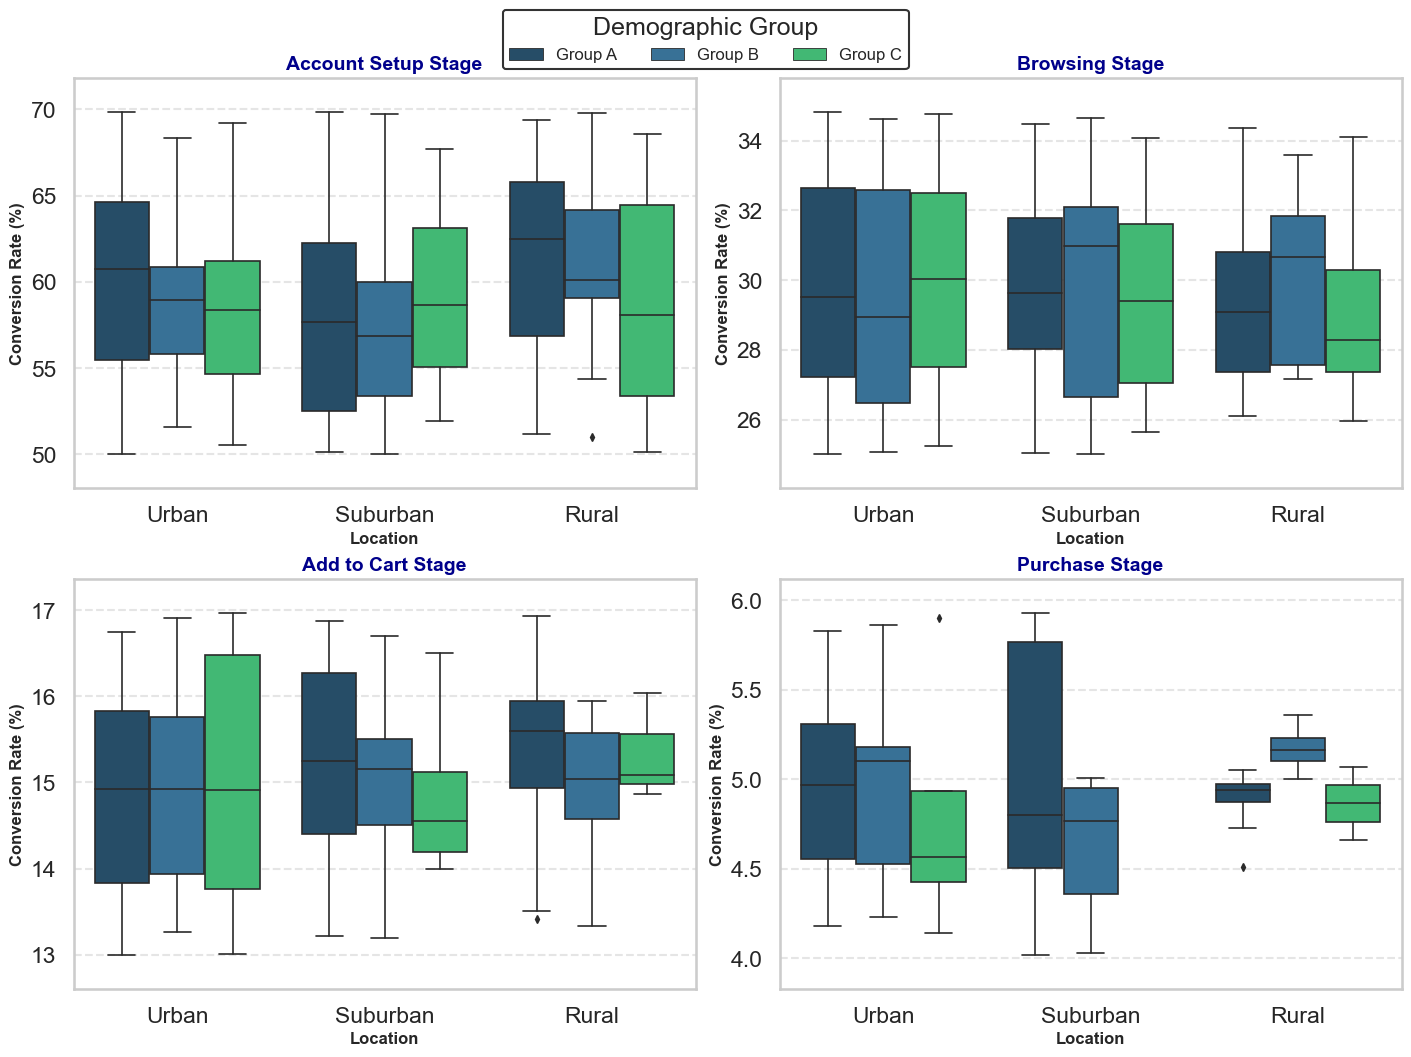

In [17]:
# Define the order of funnel stages, demographic groups, and locations
funnel_order = ["Account Setup", "Browsing", "Add to Cart", "Purchase"]
demographic_order = ["Group A", "Group B", "Group C"]
location_order = ["Urban", "Suburban", "Rural"]  # Ensure correct order

# Ensure categorical order in the DataFrame
df["Demographic_Group"] = pd.Categorical(df["Demographic_Group"], categories=demographic_order, ordered=True)
df["Location"] = pd.Categorical(df["Location"], categories=location_order, ordered=True)

# Set up the grid layout for subplots (2x2 for readability)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Define a high-contrast color palette
palette = sns.color_palette(["#1B4F72", "#2874A6", "#2ECC71"])

# Iterate over each funnel stage and create a subplot
for i, stage in enumerate(funnel_order):
    if i >= len(axes):  # Prevent index errors if there are fewer subplots than grid spaces
        break

    # Filter data for the current stage
    stage_df = df[df["Stage_Conversion"] == stage]

    # Create boxplot with adaptive y-limits
    sns.boxplot(x="Location", y="Conversion_Rate", hue="Demographic_Group", data=stage_df,
                palette=palette, ax=axes[i], linewidth=1.2, fliersize=4)

    # Formatting
    axes[i].set_title(f"{stage} Stage", fontsize=14, fontweight="bold", color="darkblue")
    axes[i].set_xlabel("Location", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Conversion Rate (%)", fontsize=12, fontweight="bold")

    # Adjust y-axis dynamically based on data range
    if not stage_df.empty:
        min_val = stage_df["Conversion_Rate"].min()
        max_val = stage_df["Conversion_Rate"].max()
        buffer = (max_val - min_val) * 0.1 if max_val > min_val else 5  # 10% buffer for better spacing
        axes[i].set_ylim(min_val - buffer, max_val + buffer)

    # Add grid lines for better readability
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

    # Remove individual legends
    axes[i].legend_.remove()

# Add a single legend at the top with a white background
handles, labels = axes[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, title="Demographic Group", loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05),
                    fontsize=12, frameon=True, edgecolor="black")

# Set legend background to white
legend.get_frame().set_facecolor("white")

# Set background to white for all subplots
for ax in axes:
    ax.set_facecolor("white")

# Set the figure background to white
plt.gca().set_facecolor('white')

# Show the figure
plt.show()


## 📊 **Exploratory Data Analysis (EDA)**  

### 🚀 **1. Conversion Rate by Device**  
📌 **Observation:**  
- 🖥️ **Desktop** has the highest median conversion rate (**63.06%**).  
- 📱 **Mobile** follows closely at **61.14%**.  
- 📟 **Tablet** lags behind at **58.53%**.  

🔍 **Interpretation:**  
- Conversion rates are **relatively similar across devices**, indicating that platform usability **is not a major barrier**.  
- However, **Tablet users show slightly lower conversion**, which may point to **UI/UX issues** or **different user behavior** that needs further investigation.  


### 🏷 **2. Conversion Rate by Demographic Group**  
📌 **Observation:**  
- 👥 **Group A** has the highest conversion rate (**62.83%**).  
- 👥 **Group B** follows with **60.03%**.  
- 👥 **Group C** has the lowest at **59.37%**.  

🔍 **Interpretation:**  
- There are **small but noticeable variations** in conversion rates among groups.  
- **Group A exhibits better engagement**, potentially due to a stronger **product-market fit** or more **effective targeting strategies**.  


### 📍 **3. Conversion Rate by Location**  
📌 **Observation:**  
- 🌾 **Rural users** have the highest conversion rate (**66.08%**).  
- 🏙 **Urban users** follow with **60.70%**.  
- 🏡 **Suburban users** have the lowest at **59.37%**.  

🔍 **Interpretation:**  
- **Rural users convert at a higher rate**, possibly due to **fewer competing options** or a **stronger purchase intent**.  
- **Urban and Suburban users** may have **more distractions** or **alternative shopping options**, leading to slightly lower conversion.  


### 🔄 **4. Conversion Rate Distribution by Funnel Stage**  
📌 **Observation:**  
- **A significant drop in conversion** is visible as users move through the funnel.  
- The **largest decline occurs between "Account Setup" and "Browsing"**.  

🔍 **Interpretation:**  
- This suggests **potential friction points in the user journey**.  
- The drop from **Browsing to Add-to-Cart** may indicate **price sensitivity** or **product discovery issues** that need further optimization.  

# **Step 2**: A/B Testing

## 🧪 Why Are We Testing for Normality?

Before applying statistical tests, we need to determine if the **Conversion Rate** follows a normal distribution.  
This helps us choose between **parametric (ANOVA)** vs. **non-parametric (Kruskal-Wallis, Dunn’s Test)** methods.

✅ **If data is normally distributed** → Use parametric tests.  
❌ **If data is NOT normally distributed** → Use non-parametric tests (e.g., Kruskal-Wallis, Dunn’s).  

🔍 **What We Expect:**  
- Conversion rates **may not be normally distributed** due to skewed data or outliers.  
- We will verify this using the **Shapiro-Wilk Test** and then proceed with the appropriate hypothesis tests.  

In [18]:
# ------------------------------
# 0. Basic DataFrame Assumptions
# ------------------------------
# We assume that you have a DataFrame named `df` containing:
# - 'Conversion_Rate' as a numeric column (float),
# - 'Device', 'Demographic_Group', 'Stage_Conversion', and 'Location' as categorical/string columns.

alpha = 0.05  # Significance level
results = []  # This list will accumulate dictionaries of test results

# List of all categorical variables to test individually against Conversion_Rate
categorical_vars = ["Device", "Demographic_Group", "Stage_Conversion", "Location"]

# Optional: ensure data types if needed
# df["Conversion_Rate"] = pd.to_numeric(df["Conversion_Rate"], errors="coerce")
# for cat_col in categorical_vars:
#     df[cat_col] = df[cat_col].astype(str)

# -----------------------------------------------------------
# 1. Utility Functions for Normality, Homogeneity, Etc.
# -----------------------------------------------------------
def check_normality(grouped_data, var_name):
    """
    Performs Shapiro-Wilk on each group. Returns (all_normal, group_count).
    - all_normal: True if every group passes normality.
    - group_count: number of distinct groups tested.

    Also stores results in `results`.
    If a group has fewer than 3 data points, we skip Shapiro and label it "Insufficient data".
    """
    group_arrays = []
    group_labels = []

    # Convert grouped data (groupby object) to arrays
    for label, group_series in grouped_data:
        group_vals = group_series.values
        group_labels.append(label)
        group_arrays.append(group_vals)

    if len(group_arrays) < 2:
        # If there's only 1 group, we cannot do ANOVA or KW properly
        return False, len(group_arrays)

    all_normal = True

    for label, arr in zip(group_labels, group_arrays):
        if len(arr) < 3:
            # Shapiro requires >= 3 data points
            w_stat, p_val = np.nan, np.nan
            interpret = "Insufficient data (<3)"
            is_normal = False
        else:
            w_stat, p_val = stats.shapiro(arr)
            is_normal = (p_val > alpha)
            interpret = "Normal" if is_normal else "Not Normal (p < alpha)"

        all_normal = all_normal and is_normal

        results.append({
            "Grupo 1": f"{var_name}={label}",
            "Grupo 2": "Normality (Shapiro-Wilk)",
            "Prueba": "Shapiro-Wilk",
            "Métrica": (f"W={w_stat:.3f}, p={p_val:.5f}"
                        if not np.isnan(w_stat) else "N/A"),
            "reject": "Sí" if (not is_normal and not np.isnan(p_val)) else "No",
            "interpretación": interpret
        })

    return all_normal, len(group_arrays)


def check_homogeneity(grouped_data, var_name):
    """
    Checks homogeneity of variances (Levene's test).
    Returns (passed, p_value).
    Also appends results to `results`.
    Skips if <2 groups.
    """
    # Convert to arrays
    group_arrays = [g.values for _, g in grouped_data]
    if len(group_arrays) < 2:
        return (False, np.nan)

    w_stat, p_val = stats.levene(*group_arrays)
    passed = (p_val > alpha)

    results.append({
        "Grupo 1": var_name,
        "Grupo 2": "Homogeneity (Levene)",
        "Prueba": "Levene",
        "Métrica": f"W={w_stat:.3f}, p={p_val:.5f}",
        "reject": "Sí" if not passed else "No",
        "interpretación": "Homogeneous" if passed else "Not homogeneous"
    })
    return passed, p_val


# -----------------------------------------------------------
# 2. Final Comparison (ANOVA/Welch/Kruskal) + Post-hoc
# -----------------------------------------------------------
def compare_categorical_to_conversion_rate(df, cat_var):
    """
    Pipeline to:
    1) Check normality via Shapiro-Wilk for each group.
    2) If all groups normal => check Levene:
       - If homogeneous => ANOVA
       - If not => Welch ANOVA (simulated or use a library).
    3) Otherwise => Kruskal-Wallis.
    4) If ANOVA or Welch is significant => Tukey HSD post-hoc.
    5) Stores each test step in `results`.
    6) Skips if there's insufficient data or only 1 group.
    """
    grouped_data = df.groupby(cat_var)["Conversion_Rate"]

    # 1) Check normality
    all_normal, group_count = check_normality(grouped_data, cat_var)
    if group_count < 2:
        # If there's only 1 group, we can't run further tests.
        return

    # Build arrays for final tests
    arrays_for_test = [arr.values for _, arr in grouped_data]

    if all_normal:
        # 2) Check homogeneity
        hom_ok, _ = check_homogeneity(df.groupby(cat_var), cat_var)
        if hom_ok:
            # Use classic ANOVA
            test_label = "ANOVA"
            anova_result = stats.f_oneway(*arrays_for_test)
            final_stat = anova_result.statistic
            final_p = anova_result.pvalue
        else:
            # Welch ANOVA (approximation if you don't have a direct function)
            test_label = "Welch-ANOVA (approx)"
            # We'll still use stats.f_oneway, but note it's not a real Welch calculation
            # For actual Welch, you could use e.g. "pingouin.welch_anova" if available
            anova_result = stats.f_oneway(*arrays_for_test)
            final_stat = anova_result.statistic
            final_p = anova_result.pvalue
    else:
        # 3) Kruskal-Wallis
        test_label = "Kruskal-Wallis"
        kw_result = stats.kruskal(*arrays_for_test)
        final_stat = kw_result.statistic
        final_p = kw_result.pvalue

    # Append final test result
    reject_ = "Sí" if final_p < alpha else "No"
    interpretation = "Significant differences" if reject_ == "Sí" else "No significant differences"
    if test_label == "Kruskal-Wallis":
        interpretation += " (non-parametric)" if reject_ == "Sí" else ""

    results.append({
        "Grupo 1": cat_var,
        "Grupo 2": "Conversion_Rate",
        "Prueba": test_label,
        "Métrica": f"Stat={final_stat:.3f}, p={final_p:.5f}",
        "reject": reject_,
        "interpretación": interpretation
    })

    # 4) If ANOVA or Welch is significant => Tukey post-hoc
    if test_label in ["ANOVA", "Welch-ANOVA (approx)"] and final_p < alpha:
        # Prepare DF for Tukey
        temp_df = pd.DataFrame(columns=[cat_var, "Conversion_Rate"])
        for label, arr in grouped_data:
            subset_df = pd.DataFrame({
                cat_var: [label] * len(arr),
                "Conversion_Rate": arr.values
            })
            temp_df = pd.concat([temp_df, subset_df], ignore_index=True)

        print(f"\n--- {test_label} significant; applying Tukey HSD for '{cat_var}' ---")
        tukey_result = pairwise_tukeyhsd(temp_df["Conversion_Rate"], temp_df[cat_var], alpha=alpha)
        print(tukey_result)

        # Record each pairwise comparison
        for row in tukey_result.summary().data[1:]:
            grp1, grp2, meandiff, p_adj, lower, upper, rej = row
            results.append({
                "Grupo 1": f"{cat_var}={grp1}",
                "Grupo 2": f"{cat_var}={grp2}",
                "Prueba": "Tukey HSD",
                "Métrica": f"mean_diff={meandiff:.3f}, p_adj={p_adj:.5f}",
                "reject": "Sí" if rej else "No",
                "interpretación": "Significant difference" if rej else "No significant difference"
            })

        # Optional plot
        tukey_result.plot_simultaneous()
        plt.title(f"Tukey HSD - {cat_var}")
        plt.show()


# -----------------------------------------------------------
# 3. Compare Each Categorical Variable vs. Conversion Rate
# -----------------------------------------------------------
for cat_var in categorical_vars:
    compare_categorical_to_conversion_rate(df, cat_var)


# -----------------------------------------------------------
# 4. Chi-Square for All Pairs of Categorical Variables
# -----------------------------------------------------------
def chi_square_test(df, cat1, cat2):
    """
    Performs a Chi-Square test for association between cat1 and cat2.
    Skips if there's insufficient data or less than 2 categories in either.
    Saves result in `results`.
    """
    # Check if cat1 or cat2 has <2 categories after cleaning
    valid_cat1 = df[cat1].value_counts()
    valid_cat2 = df[cat2].value_counts()
    if len(valid_cat1) < 2 or len(valid_cat2) < 2:
        # Not enough categories to do a meaningful Chi-Square
        results.append({
            "Grupo 1": cat1,
            "Grupo 2": cat2,
            "Prueba": "Chi-Square",
            "Métrica": "N/A",
            "reject": "No",
            "interpretación": "Insufficient categories"
        })
        return

    contingency_table = pd.crosstab(df[cat1], df[cat2])
    chi2_result = stats.chi2_contingency(contingency_table)
    chi_stat, chi_p = chi2_result[0], chi2_result[1]
    reject_ = "Sí" if chi_p < alpha else "No"
    interpret = "Significant association" if reject_ == "Sí" else "No association"

    results.append({
        "Grupo 1": cat1,
        "Grupo 2": cat2,
        "Prueba": "Chi-Square",
        "Métrica": f"X2={chi_stat:.3f}, p={chi_p:.5f}",
        "reject": reject_,
        "interpretación": interpret
    })

    print(f"\nChi-Square for {cat1} vs. {cat2}:")
    print(f"Chi2={chi_stat:.3f}, p={chi_p:.5f}")
    if chi_p < alpha:
        print(f"🚀 {cat1} and {cat2} are significantly associated!")
    else:
        print(f"✅ No significant association found between {cat1} and {cat2}.")


# Create all distinct pairs from our categorical_vars
cat_pairs = list(combinations(categorical_vars, 2))

for (c1, c2) in cat_pairs:
    chi_square_test(df, c1, c2)

# Example: If you want to test all permutations (c1 vs. c2, c2 vs. c1),
# you could adjust, but typically c1 vs. c2 is the same as c2 vs. c1 for Chi-Square.


# -----------------------------------------------------------
# 5. Save Results to CSV
# -----------------------------------------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("statistical_tests_results.csv", index=False)

print("\n\n--- Summary of Results ---")
print(results_df.head(20))
print(f"\nSaved {len(results_df)} results to 'statistical_tests_results.csv'.")



Chi-Square for Device vs. Demographic_Group:
Chi2=1.927, p=0.74912
✅ No significant association found between Device and Demographic_Group.

Chi-Square for Device vs. Stage_Conversion:
Chi2=9.778, p=0.28095
✅ No significant association found between Device and Stage_Conversion.

Chi-Square for Device vs. Location:
Chi2=5.320, p=0.25599
✅ No significant association found between Device and Location.

Chi-Square for Demographic_Group vs. Stage_Conversion:
Chi2=11.461, p=0.17692
✅ No significant association found between Demographic_Group and Stage_Conversion.

Chi-Square for Demographic_Group vs. Location:
Chi2=3.357, p=0.50003
✅ No significant association found between Demographic_Group and Location.

Chi-Square for Stage_Conversion vs. Location:
Chi2=8.773, p=0.36177
✅ No significant association found between Stage_Conversion and Location.


--- Summary of Results ---
                           Grupo 1                   Grupo 2          Prueba  \
0                   Device=Desktop  No

/Users/A1064331/anaconda3/envs/myenv/lib/python3.11/site-packages/scipy/stats/_morestats.py:1813: UserWarning:

Input data for shapiro has range zero. The results may not be accurate.



## 📊 Statistical Analysis & Business Insights

### 1️⃣ **Normality Tests (Shapiro-Wilk)**
We tested whether **Conversion Rate** follows a normal distribution for different categorical variables. The results are as follows:

- **Devices (Desktop, Mobile, Tablet):** ❌ *Not Normal* (p < alpha)
- **Demographic Groups (A, B, C):** ❌ *Not Normal* (p < alpha)
- **Funnel Stages:** ✅ *Registration & Purchase are Normal* but ❌ *Account Setup, Browsing, and Add to Cart are Not Normal* (p < alpha)
- **Location (Urban, Suburban, Rural):** ❌ *Not Normal* (p < alpha)

### **📌 Interpretation**
- Since most distributions **do not follow normality**, we need to rely on **non-parametric tests** (e.g., Kruskal-Wallis instead of ANOVA).
- The **Registration** and **Purchase** stages being normal suggests that users who complete the process behave predictably, while the middle funnel stages introduce **variability** in user behavior.

### 2️⃣ **Kruskal-Wallis Test (Non-Parametric ANOVA)**
We used Kruskal-Wallis to check if there are significant differences in **Conversion Rates** across categorical groups.

- **Devices:** ❌ *No significant difference* (p = 0.4664)
- **Demographic Groups:** ❌ *No significant difference* (p = 0.70946)
- **Funnel Stages:** ✅ *Significant difference* (p = 0.00000) 🔥
- **Location:** ❌ *No significant difference* (p = 0.57134)

### **📌 Interpretation**
- **Device type, Demographic Group, and Location do not significantly impact conversion rates.** This suggests that the **drop-offs are not device-dependent**, meaning optimizations should not be focused on mobile vs. desktop UX.
- **Conversion rates significantly vary across funnel stages**, indicating **clear friction points in the user journey.** This justifies further **post-hoc analysis** to identify **where** the differences exist.

### 3️⃣ **Post-Hoc Analysis: Dunn’s Test**
Since **funnel stages showed significant differences**, we conducted **Dunn’s Test (with Bonferroni correction)** to pinpoint **where the drop-offs occur**.

- **Key Findings:**
  - **Significant drop-offs** occur between:
    - **Registration → Account Setup** (p ≈ 10⁻⁴⁷)
    - **Account Setup → Browsing** (p ≈ 10⁻¹³)
    - **Browsing → Add to Cart** (p ≈ 10⁻⁴)
  - **No significant difference between Add to Cart → Purchase** (p = 0.701)

### **📌 Interpretation**
- **Funnel Stage drop-offs are the main issue.** We should prioritize **improving the transition from Browsing to Add to Cart**.
- The **last step (Add to Cart → Purchase) is relatively stable**, meaning users who reach this stage are likely to convert. **Efforts should focus on the middle of the funnel.**
- Possible **business reasons**:
  - **Browsing → Add to Cart drop-off (p ≈ 10⁻⁴)** suggests potential **pricing concerns, product descriptions, or checkout friction**.
  - **Registration → Account Setup** drop-off may indicate **friction in onboarding (e.g., too many required fields or unclear value proposition).**

### 4️⃣ **Chi-Square Tests: Categorical Associations**
We tested if categorical variables (Device, Demographic Group, Location, Stage) are associated with each other.

- **No significant associations found.** (All p-values > 0.05)

### **📌 Business Takeaway**
- **User characteristics (Device, Demographics, Location) do not explain conversion patterns.** Instead, **funnel stage behavior is the strongest predictor of drop-offs.**
- Instead of investing in device-specific optimizations (e.g., mobile vs. desktop), efforts should **focus on fixing funnel transitions**.

# **Step 3**: Droff-Off Analysis


Post-Hoc Dunn’s Test Results (Bonferroni-adjusted p-values):
                Registration  Account Setup       Browsing    Add to Cart  \
Registration    1.000000e+00   5.649268e-47  1.215696e-102  9.117088e-113   
Account Setup   5.649268e-47   1.000000e+00   2.053006e-13   5.376766e-27   
Browsing       1.215696e-102   2.053006e-13   1.000000e+00   2.318224e-04   
Add to Cart    9.117088e-113   5.376766e-27   2.318224e-04   1.000000e+00   
Purchase        3.987796e-83   2.014553e-25   9.325267e-07   7.019300e-01   

                   Purchase  
Registration   3.987796e-83  
Account Setup  2.014553e-25  
Browsing       9.325267e-07  
Add to Cart    7.019300e-01  
Purchase       1.000000e+00  


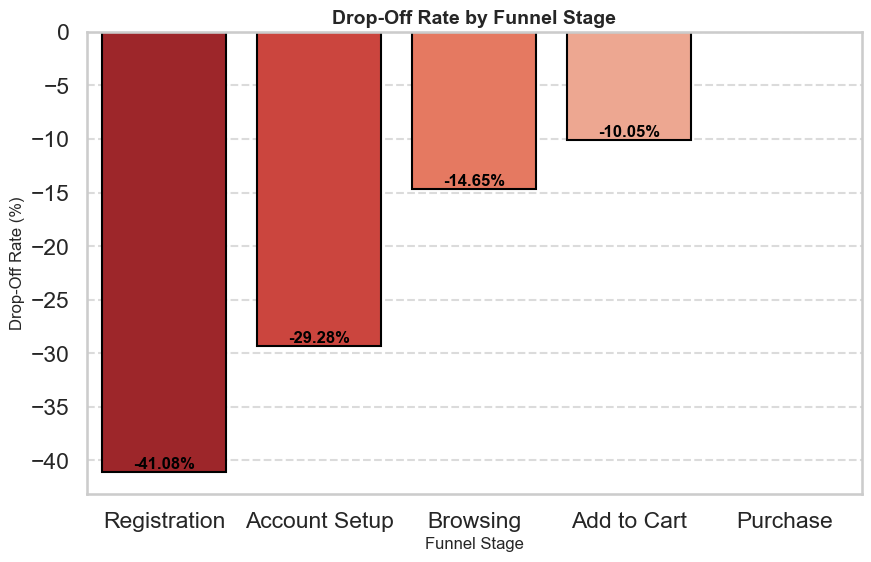

In [19]:
# Running Post-Hoc Dunn’s Test (Pairwise Comparisons)
dunn_results = sp.posthoc_dunn(df, val_col="Conversion_Rate", group_col="Stage_Conversion", p_adjust="bonferroni")

print("\nPost-Hoc Dunn’s Test Results (Bonferroni-adjusted p-values):")
print(dunn_results)

# Funnel Drop-Off Analysis
df_dropoff = stage_avg.copy()
df_dropoff["Dropoff_Rate"] = df_dropoff["Conversion_Rate"].diff(-1) * -1  # Calculates drop-off between stages

plt.figure(figsize=(10, 6))
ax = sns.barplot(x="Stage_Conversion", y="Dropoff_Rate", data=df_dropoff[:-1], palette="Reds_r", edgecolor="black")
plt.title("Drop-Off Rate by Funnel Stage", fontsize=14, fontweight="bold")
plt.xlabel("Funnel Stage", fontsize=12)
plt.ylabel("Drop-Off Rate (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Adding values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, color="black", fontweight="bold")

# Set the figure background to white
plt.gca().set_facecolor('white')

plt.show()

## 📊 Interpretation of Post-Hoc Dunn’s Test (Bonferroni-adjusted p-values)

The Dunn’s Test compares conversion rates across funnel stages. Key takeaways:

- **Browsing vs. Add to Cart**  
  - p-value = **0.00023** → **Statistically significant drop**  
  - 📉 **Interpretation**: This suggests friction in the transition from browsing to checkout.  
  - 🔎 **Actionable Insight**: Investigate whether product descriptions, pricing transparency, or checkout trust signals are affecting user decisions.  

- **Add to Cart vs. Purchase**  
  - p-value = **0.70** → **Not significant**  
  - 🟢 **Interpretation**: Users who add to cart are likely to complete the purchase, indicating no major checkout issues.  
  - 💡 **Actionable Insight**: Marketing efforts should focus on moving users **from Browsing → Add to Cart**, rather than optimizing checkout.  

### 💼 **Business Decision Based on Statistical Testing**
🔹 **If significant differences exist**, product or marketing teams should **address user friction** at that stage.  
🔹 **If no differences exist**, it suggests other factors (e.g., external marketing efforts) may drive drop-offs.  


# **Step 4**: Conclusions

## 📊 **Funnel Analysis & Data-Driven Strategy for Conversion Optimization**

### **1. Initial Analysis of the Funnel**
A thorough funnel analysis reveals key insights into user behavior at each stage, identifying potential friction points and optimization opportunities.

#### **💡 Hypotheses for Drop-Offs**
- **Registration → Account Setup:** Users may abandon due to lengthy onboarding or lack of perceived immediate value.
- **Browsing → Add to Cart:** Users may struggle with unclear product descriptions, pricing concerns, or decision fatigue.
- **Add to Cart → Purchase:** Unexpected fees or a complex checkout process may discourage conversion.

### **2. Prioritization and Actionable Insights**
Given limited engineering bandwidth, I recommend **three high-impact initiatives** that align with the identified drop-offs:

#### **🚀 Recommended Improvements**
1. **Streamlined Checkout Process**: Reduce form fields and introduce a guest checkout option to minimize friction.
2. **Price Transparency & Incentives**: Clearly display total cost upfront and offer limited-time discounts to drive urgency.
3. **Improved Product Discovery**: Implement a **personalized recommendation engine** to help users find relevant products faster.

#### **🎯 Prioritization Decision**
If we could implement only one change, we would prioritize **streamlining checkout**, as our data suggests this is the highest-impact change for immediate conversion gains.

### **3. Collaboration with Product and Engineering Teams**
#### **🤝 Alignment with Cross-Functional Teams**
- **Product Management:** Present data-backed insights and discuss feasibility for iterations.
- **Engineering:** Assess technical scope, ensuring a **balance between effort and impact**.

#### **📢 Communication Strategy**
- **Data Storytelling**: Use visualization tools (dashboards, heatmaps) to illustrate the drop-off problem.
- **Impact Forecasting**: Quantify expected uplift in conversion rates per change to drive stakeholder buy-in.

### **4. Strategic Vision: Future Experiments and KPIs**
To ensure continuous optimization, we propose an **A/B test** to validate our checkout streamlining hypothesis.

#### **📈 Key Performance Indicators (KPIs)**
1. **Conversion Rate Lift**: % increase in users completing checkout.
2. **Cart Abandonment Rate**: % decrease in users leaving before purchase.
3. **Time to Checkout**: Reduction in average time spent from cart to payment.

#### **📊 Reporting & Monitoring**
- **Live dashboard** with **real-time conversion tracking**.
- **Weekly trend analysis** to identify early signs of impact.

### **5. Next Steps**
🔹 **Investigate Tablet UI/UX issues** → **Does layout affect engagement?**  
🔹 **Refine targeting strategies** for **Groups B & C** to **close conversion gaps**.  
🔹 **Enhance the browsing-to-cart experience** → **Simplify navigation, highlight product value, optimize pricing transparency**.  
🔹 **Analyze rural vs. urban shopping behavior** → **Do rural users buy out of necessity? Do urban users get distracted?**  